Running Peer Learning Comparison...


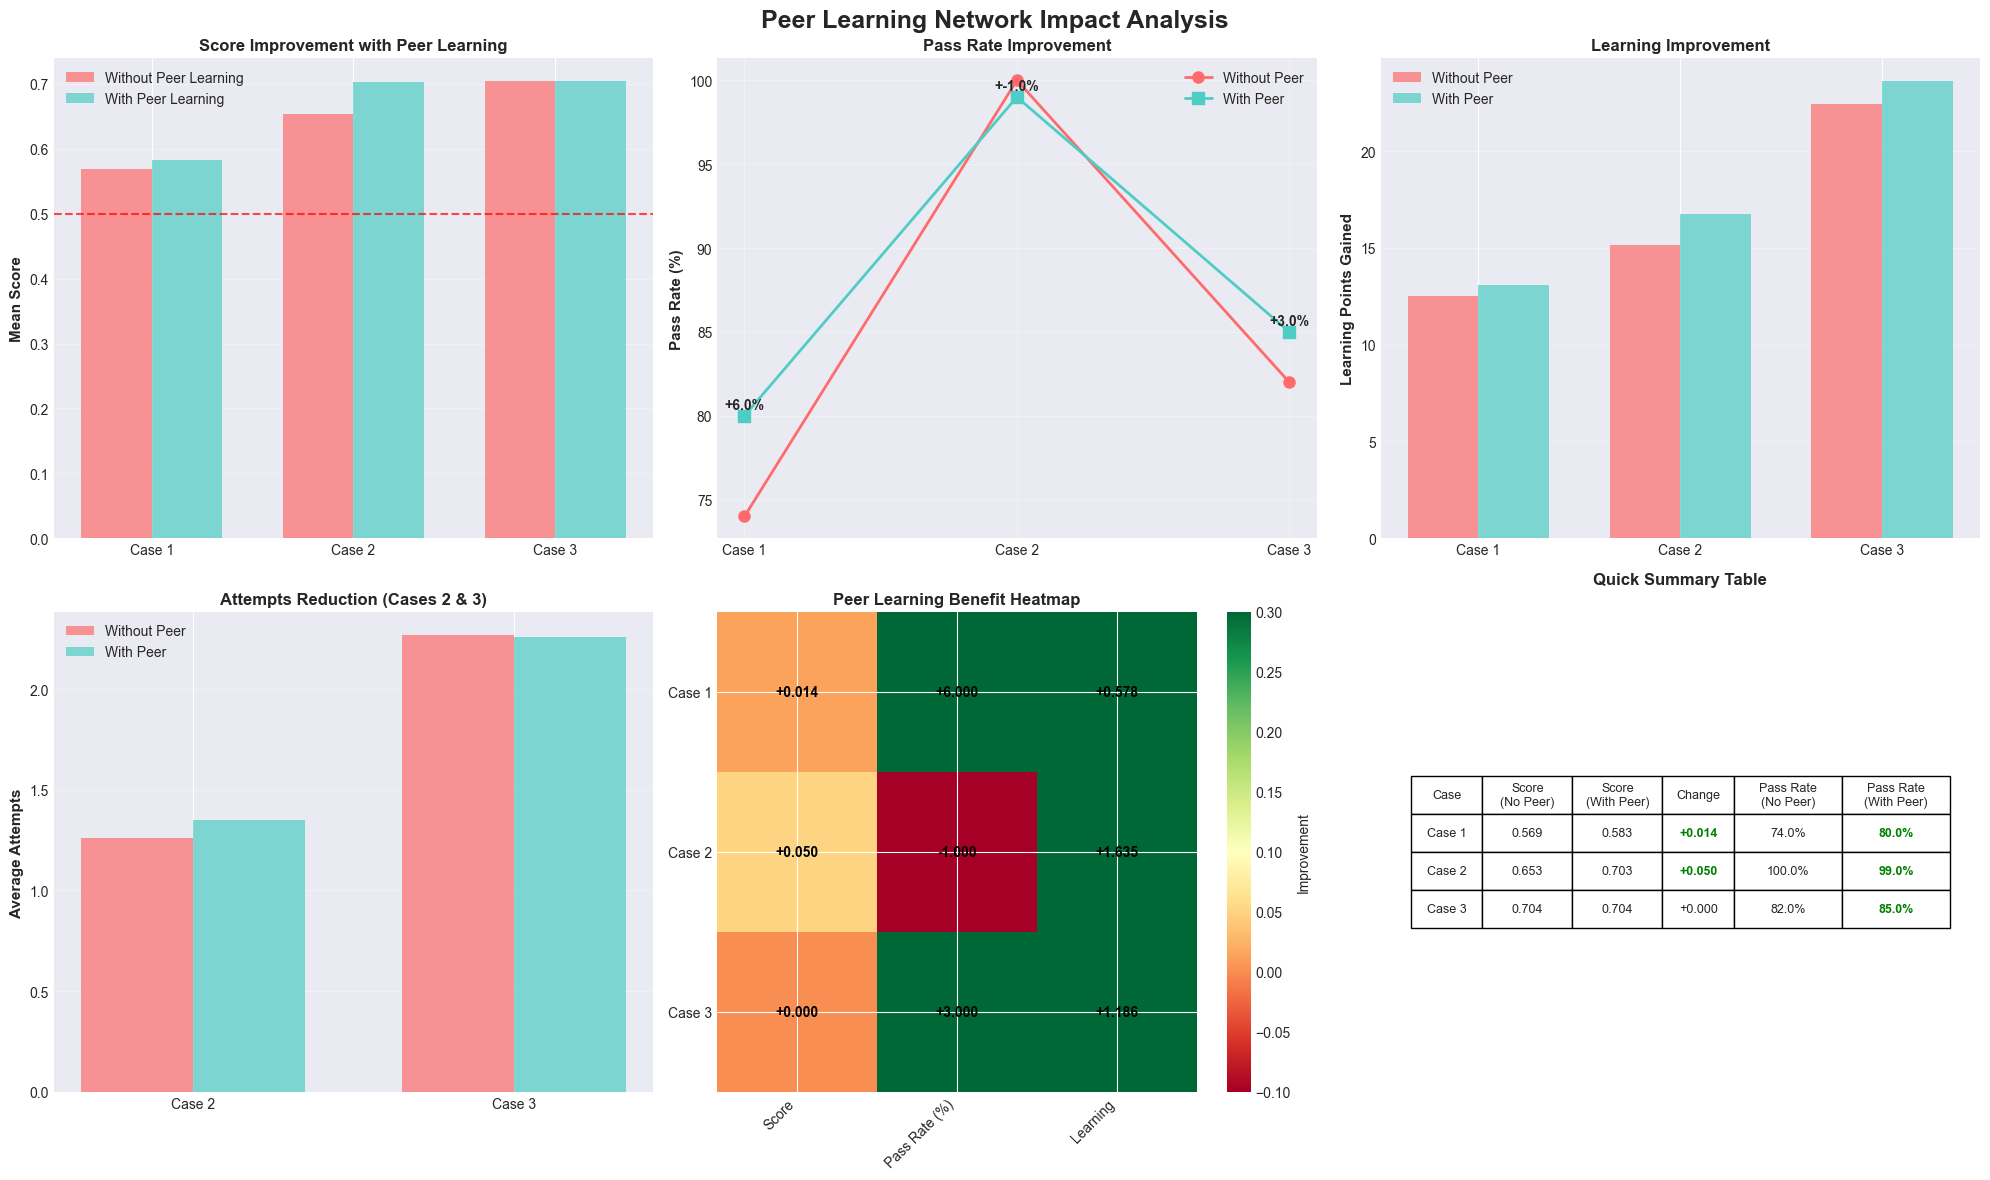

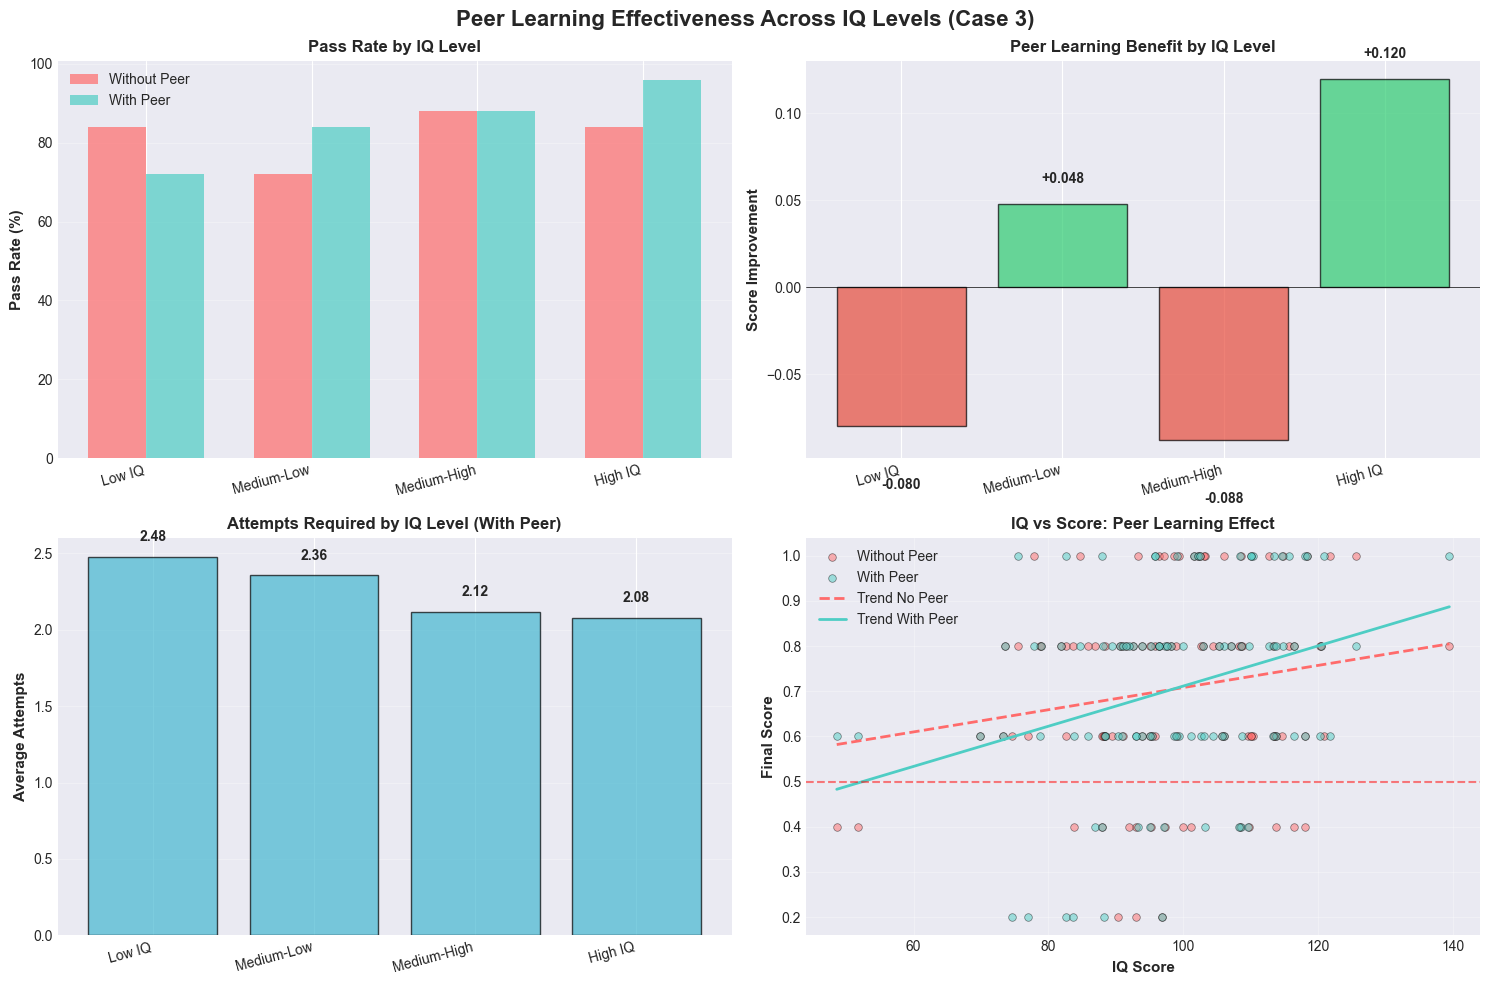


PEER LEARNING NETWORK: STATISTICAL SUMMARY

📚 Case 1 (No Personalization)
----------------------------------------------------------------------
Metric                    Without Peer         With Peer            Improvement    
----------------------------------------------------------------------
Mean Score                0.569                0.583                +0.014
Pass Rate (%)             74.0                 80.0                 +6.0%
Learning Gain             12.5                 13.1                 +0.6
Avg Attempts              1.00                 1.00                 +0.00
Score Std Dev             0.170                0.179                +0.008

📚 Case 2 (Reinforcement)
----------------------------------------------------------------------
Metric                    Without Peer         With Peer            Improvement    
----------------------------------------------------------------------
Mean Score                0.653                0.703                +0.050
P

In [1]:
# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import copy
import warnings
warnings.filterwarnings('ignore')

# Parameters
mu, sigma = 100, 15 
students = 100
num_of_questions = 10
reinforcement_questions = 5

WEIGHT = 20
PASS_THRESHOLD = 0.5
MAX_ATTEMPTS = 5

DIFFICULTY = ["easy", "medium", "hard"]
PROBABILITIES = [0.7, 0.2, 0.1]
REINFORCEMENT_PROB = [0.8, 0.2, 0.0]

IQ_QUANTILES = {
    "easy": 0.10,
    "medium": 0.50,
    "hard": 0.90
}

# %%
# Core Functions
def generate_students(n):
    iq_scores = np.random.normal(mu, sigma, n)
    return [{"iq": iq, "learning": 50} for iq in iq_scores]

def generate_questions(n, probs):
    return list(np.random.choice(DIFFICULTY, size=n, p=probs))

def compute_probability(student, difficulty):
    iq = student["iq"]
    learning = student["learning"]
    quantile = IQ_QUANTILES[difficulty]
    
    A_i = (iq + learning) / (WEIGHT * quantile * 100)
    return min(1, A_i)

def answer_question(student, difficulty, peer_boost=1.0):
    prob = compute_probability(student, difficulty)
    prob = min(1.0, prob * peer_boost)
    result = np.random.binomial(1, prob)
    
    if result == 1:
        gain_multiplier = peer_boost
        if difficulty == "easy":
            student["learning"] += 2 * gain_multiplier
        elif difficulty == "medium":
            student["learning"] += 5 * gain_multiplier
        elif difficulty == "hard":
            student["learning"] += 10 * gain_multiplier
    
    return result

def run_questions(student, n, probs, peer_boost=1.0):
    questions = generate_questions(n, probs)
    results = [answer_question(student, q, peer_boost) for q in questions]
    return np.mean(results)

# %%
# Peer Learning Network Class
class PeerLearningNetwork:
    """Students can learn from peers and form study groups"""
    
    def __init__(self, student_list):
        self.network = {i: [] for i in range(len(student_list))}
        self.study_groups = []
        
    def form_study_groups(self, students, n_groups=None):
        """Form groups based on IQ and learning style similarity"""
        if n_groups is None:
            n_groups = min(5, max(2, len(students)//20))
        
        features = np.array([[s['iq'], s['learning']] for s in students])
        
        if len(students) < n_groups:
            n_groups = max(1, len(students) // 2)
        
        if n_groups <= 1 or len(students) <= 2:
            self.study_groups = [list(range(len(students)))]
        else:
            kmeans = KMeans(n_clusters=n_groups, random_state=42, n_init=10)
            groups = kmeans.fit_predict(features)
            
            self.study_groups = [[] for _ in range(max(groups)+1)]
            for idx, group_id in enumerate(groups):
                self.study_groups[group_id].append(idx)
        
        return self.study_groups
    
    def peer_learning_effect(self, student_idx, students):
        """Calculate learning boost from peers"""
        if not self.study_groups:
            return 1.0
            
        group_id = None
        for gid, group in enumerate(self.study_groups):
            if student_idx in group:
                group_id = gid
                break
        
        if group_id is None or len(self.study_groups[group_id]) <= 1:
            return 1.0
        
        group = self.study_groups[group_id]
        group_avg_learning = np.mean([students[i]['learning'] for i in group])
        group_avg_iq = np.mean([students[i]['iq'] for i in group])
        
        if students[student_idx]['learning'] < group_avg_learning:
            gap_ratio = (group_avg_learning - students[student_idx]['learning']) / 50
            boost = 1 + 0.15 * gap_ratio
        else:
            n_lower = len([i for i in group if students[i]['learning'] < students[student_idx]['learning']])
            boost = 1 + 0.08 * min(3, n_lower)
        
        if students[student_idx]['iq'] < group_avg_iq - 10:
            boost *= 0.95
        elif students[student_idx]['iq'] > group_avg_iq + 10:
            boost *= 1.05
        
        return min(1.5, max(0.85, boost))

# %%
# Case Implementations
def run_case1_no_peer(student_list):
    scores = []
    for student in student_list:
        score = run_questions(student, num_of_questions, PROBABILITIES, 1.0)
        scores.append(score)
    return scores

def run_case1_with_peer(student_list, peer_network):
    scores = []
    for idx, student in enumerate(student_list):
        peer_boost = peer_network.peer_learning_effect(idx, student_list)
        score = run_questions(student, num_of_questions, PROBABILITIES, peer_boost)
        scores.append(score)
    return scores

def run_module_case2(student, peer_boost=1.0):
    score = run_questions(student, num_of_questions, PROBABILITIES, peer_boost)
    attempts = 1
    
    while score < PASS_THRESHOLD and attempts < MAX_ATTEMPTS:
        score = run_questions(student, reinforcement_questions, REINFORCEMENT_PROB, peer_boost)
        attempts += 1
    
    return score, attempts

def run_case2_no_peer(student_list):
    scores, attempts = [], []
    for student in student_list:
        s, a = run_module_case2(student, 1.0)
        scores.append(s)
        attempts.append(a)
    return scores, attempts

def run_case2_with_peer(student_list, peer_network):
    scores, attempts = [], []
    for idx, student in enumerate(student_list):
        peer_boost = peer_network.peer_learning_effect(idx, student_list)
        s, a = run_module_case2(student, peer_boost)
        scores.append(s)
        attempts.append(a)
    return scores, attempts

def teacher_intervention(student):
    student["learning"] += 15

def run_case3_no_peer(student_list):
    results = []
    for student in student_list:
        score, attempts = run_module_case2(student, 1.0)
        results.append([student, score, attempts])
    
    failed_students = [r for r in results if r[1] < PASS_THRESHOLD]
    for student, _, _ in failed_students:
        teacher_intervention(student)
    
    final_scores, final_attempts = [], []
    for student, _, attempts in results:
        score = run_questions(student, reinforcement_questions, REINFORCEMENT_PROB, 1.0)
        final_scores.append(score)
        final_attempts.append(attempts + 1)
    
    return final_scores, final_attempts

def run_case3_with_peer(student_list, peer_network):
    results = []
    for idx, student in enumerate(student_list):
        peer_boost = peer_network.peer_learning_effect(idx, student_list)
        score, attempts = run_module_case2(student, peer_boost)
        results.append([student, score, attempts, idx])
    
    failed_students = [r for r in results if r[1] < PASS_THRESHOLD]
    for student, _, _, _ in failed_students:
        teacher_intervention(student)
    
    final_scores, final_attempts = [], []
    for student, _, attempts, idx in results:
        peer_boost = peer_network.peer_learning_effect(idx, student_list)
        score = run_questions(student, reinforcement_questions, REINFORCEMENT_PROB, peer_boost)
        final_scores.append(score)
        final_attempts.append(attempts + 1)
    
    return final_scores, final_attempts

# %%
# Run Comparison: Without vs With Peer Learning
def run_peer_comparison(n_students=100):
    # Generate base students
    base_students = generate_students(n_students)
    
    # WITHOUT PEER LEARNING
    students_c1_no = copy.deepcopy(base_students)
    students_c2_no = copy.deepcopy(base_students)
    students_c3_no = copy.deepcopy(base_students)
    
    scores_c1_no = run_case1_no_peer(students_c1_no)
    scores_c2_no, attempts_c2_no = run_case2_no_peer(students_c2_no)
    scores_c3_no, attempts_c3_no = run_case3_no_peer(students_c3_no)
    
    # WITH PEER LEARNING
    students_c1_peer = copy.deepcopy(base_students)
    students_c2_peer = copy.deepcopy(base_students)
    students_c3_peer = copy.deepcopy(base_students)
    
    peer_c1 = PeerLearningNetwork(students_c1_peer)
    peer_c2 = PeerLearningNetwork(students_c2_peer)
    peer_c3 = PeerLearningNetwork(students_c3_peer)
    
    peer_c1.form_study_groups(students_c1_peer)
    peer_c2.form_study_groups(students_c2_peer)
    peer_c3.form_study_groups(students_c3_peer)
    
    scores_c1_peer = run_case1_with_peer(students_c1_peer, peer_c1)
    scores_c2_peer, attempts_c2_peer = run_case2_with_peer(students_c2_peer, peer_c2)
    scores_c3_peer, attempts_c3_peer = run_case3_with_peer(students_c3_peer, peer_c3)
    
    # Create dataframes
    def create_df(students, scores, attempts=None, case_name=""):
        df = pd.DataFrame({
            'iq': [s['iq'] for s in students],
            'final_learning': [s['learning'] for s in students],
            'final_score': scores,
            'passed': [1 if s >= PASS_THRESHOLD else 0 for s in scores],
            'case': case_name
        })
        if attempts is not None:
            df['attempts'] = attempts
        else:
            df['attempts'] = 1
        return df
    
    df_c1_no = create_df(students_c1_no, scores_c1_no, case_name="C1_NoPeer")
    df_c2_no = create_df(students_c2_no, scores_c2_no, attempts_c2_no, "C2_NoPeer")
    df_c3_no = create_df(students_c3_no, scores_c3_no, attempts_c3_no, "C3_NoPeer")
    
    df_c1_peer = create_df(students_c1_peer, scores_c1_peer, case_name="C1_Peer")
    df_c2_peer = create_df(students_c2_peer, scores_c2_peer, attempts_c2_peer, "C2_Peer")
    df_c3_peer = create_df(students_c3_peer, scores_c3_peer, attempts_c3_peer, "C3_Peer")
    
    return df_c1_no, df_c2_no, df_c3_no, df_c1_peer, df_c2_peer, df_c3_peer

# %%
# Run the comparison
print("Running Peer Learning Comparison...")
df_c1_no, df_c2_no, df_c3_no, df_c1_peer, df_c2_peer, df_c3_peer = run_peer_comparison(100)

# %%
# Visualization 1: Peer Learning Impact Dashboard
plt.style.use('seaborn-v0_8-darkgrid')
fig = plt.figure(figsize=(20, 12))
fig.suptitle('Peer Learning Network Impact Analysis', fontsize=18, fontweight='bold')

# 1. Score Improvement with Peer Learning
ax1 = plt.subplot(2, 3, 1)
cases = ['Case 1', 'Case 2', 'Case 3']
scores_no_peer = [df_c1_no['final_score'].mean(), df_c2_no['final_score'].mean(), df_c3_no['final_score'].mean()]
scores_peer = [df_c1_peer['final_score'].mean(), df_c2_peer['final_score'].mean(), df_c3_peer['final_score'].mean()]

x = np.arange(3)
width = 0.35
bars1 = ax1.bar(x - width/2, scores_no_peer, width, label='Without Peer Learning', color='#FF6B6B', alpha=0.7)
bars2 = ax1.bar(x + width/2, scores_peer, width, label='With Peer Learning', color='#4ECDC4', alpha=0.7)
ax1.set_ylabel('Mean Score', fontsize=11, fontweight='bold')
ax1.set_title('Score Improvement with Peer Learning', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(cases)
ax1.legend()
ax1.axhline(y=PASS_THRESHOLD, color='red', linestyle='--', alpha=0.7)
ax1.grid(True, alpha=0.3, axis='y')

# 2. Pass Rate Improvement
ax2 = plt.subplot(2, 3, 2)
pass_no_peer = [df_c1_no['passed'].mean()*100, df_c2_no['passed'].mean()*100, df_c3_no['passed'].mean()*100]
pass_peer = [df_c1_peer['passed'].mean()*100, df_c2_peer['passed'].mean()*100, df_c3_peer['passed'].mean()*100]

ax2.plot(cases, pass_no_peer, 'o-', label='Without Peer', linewidth=2, markersize=8, color='#FF6B6B')
ax2.plot(cases, pass_peer, 's-', label='With Peer', linewidth=2, markersize=8, color='#4ECDC4')
ax2.set_ylabel('Pass Rate (%)', fontsize=11, fontweight='bold')
ax2.set_title('Pass Rate Improvement', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Add improvement annotations
for i in range(3):
    improvement = pass_peer[i] - pass_no_peer[i]
    ax2.annotate(f'+{improvement:.1f}%', xy=(i, pass_peer[i]), 
                xytext=(0, 5), textcoords="offset points", ha='center', fontweight='bold')

# 3. Learning Gain Comparison
ax3 = plt.subplot(2, 3, 3)
initial_learning = 50
learning_no_peer = [df_c1_no['final_learning'].mean()-initial_learning, 
                    df_c2_no['final_learning'].mean()-initial_learning,
                    df_c3_no['final_learning'].mean()-initial_learning]
learning_peer = [df_c1_peer['final_learning'].mean()-initial_learning,
                 df_c2_peer['final_learning'].mean()-initial_learning,
                 df_c3_peer['final_learning'].mean()-initial_learning]

ax3.bar(x - width/2, learning_no_peer, width, label='Without Peer', color='#FF6B6B', alpha=0.7)
ax3.bar(x + width/2, learning_peer, width, label='With Peer', color='#4ECDC4', alpha=0.7)
ax3.set_ylabel('Learning Points Gained', fontsize=11, fontweight='bold')
ax3.set_title('Learning Improvement', fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(cases)
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# 4. Attempts Reduction
ax4 = plt.subplot(2, 3, 4)
attempts_no_peer = [df_c2_no['attempts'].mean(), df_c3_no['attempts'].mean()]
attempts_peer = [df_c2_peer['attempts'].mean(), df_c3_peer['attempts'].mean()]

x2 = np.arange(2)
ax4.bar(x2 - width/2, attempts_no_peer, width, label='Without Peer', color='#FF6B6B', alpha=0.7)
ax4.bar(x2 + width/2, attempts_peer, width, label='With Peer', color='#4ECDC4', alpha=0.7)
ax4.set_ylabel('Average Attempts', fontsize=11, fontweight='bold')
ax4.set_title('Attempts Reduction (Cases 2 & 3)', fontsize=12, fontweight='bold')
ax4.set_xticks(x2)
ax4.set_xticklabels(['Case 2', 'Case 3'])
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# 5. Performance Heatmap
ax5 = plt.subplot(2, 3, 5)
improvement_matrix = np.array([
    [scores_peer[0]-scores_no_peer[0], pass_peer[0]-pass_no_peer[0], learning_peer[0]-learning_no_peer[0]],
    [scores_peer[1]-scores_no_peer[1], pass_peer[1]-pass_no_peer[1], learning_peer[1]-learning_no_peer[1]],
    [scores_peer[2]-scores_no_peer[2], pass_peer[2]-pass_no_peer[2], learning_peer[2]-learning_no_peer[2]]
])

im = ax5.imshow(improvement_matrix, cmap='RdYlGn', aspect='auto', vmin=-0.1, vmax=0.3)
ax5.set_xticks(range(3))
ax5.set_yticks(range(3))
ax5.set_xticklabels(['Score', 'Pass Rate (%)', 'Learning'], rotation=45, ha='right')
ax5.set_yticklabels(['Case 1', 'Case 2', 'Case 3'])
ax5.set_title('Peer Learning Benefit Heatmap', fontsize=12, fontweight='bold')

for i in range(3):
    for j in range(3):
        text = ax5.text(j, i, f'{improvement_matrix[i, j]:+.3f}',
                       ha="center", va="center", color="black", fontweight='bold')

plt.colorbar(im, ax=ax5, label='Improvement')

# 6. Summary Statistics Table
ax6 = plt.subplot(2, 3, 6)
ax6.axis('tight')
ax6.axis('off')

summary_data = []
for case, df_no, df_peer in zip(['Case 1', 'Case 2', 'Case 3'], 
                                  [df_c1_no, df_c2_no, df_c3_no],
                                  [df_c1_peer, df_c2_peer, df_c3_peer]):
    summary_data.append([
        case,
        f"{df_no['final_score'].mean():.3f}",
        f"{df_peer['final_score'].mean():.3f}",
        f"{df_peer['final_score'].mean()-df_no['final_score'].mean():+.3f}",
        f"{df_no['passed'].mean()*100:.1f}%",
        f"{df_peer['passed'].mean()*100:.1f}%"
    ])

columns = ['Case', 'Score\n(No Peer)', 'Score\n(With Peer)', 'Change', 'Pass Rate\n(No Peer)', 'Pass Rate\n(With Peer)']
table = ax6.table(cellText=summary_data, colLabels=columns, 
                  cellLoc='center', loc='center',
                  colWidths=[0.12, 0.15, 0.15, 0.12, 0.18, 0.18])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

for i in range(3):
    for j in range(len(columns)):
        if j in [3, 5] and i < 3:
            cell = table[(i+1, j)]
            value = float(summary_data[i][j].replace('%', '')) if '%' in summary_data[i][j] else float(summary_data[i][j])
            if j == 3 and value > 0:
                cell.set_text_props(color='green', fontweight='bold')
            elif j == 5 and value > 0:
                cell.set_text_props(color='green', fontweight='bold')

ax6.set_title('Quick Summary Table', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# %%
# Visualization 2: Peer Learning Effectiveness by IQ Level
fig2 = plt.figure(figsize=(15, 10))
fig2.suptitle('Peer Learning Effectiveness Across IQ Levels (Case 3)', fontsize=16, fontweight='bold')

# Create IQ segments
iq_segments = pd.qcut(df_c3_no['iq'], q=4, labels=['Low IQ', 'Medium-Low', 'Medium-High', 'High IQ'])

# 1. Pass Rate by IQ
ax1 = plt.subplot(2, 2, 1)
pass_no_by_iq = df_c3_no.groupby(iq_segments)['passed'].mean() * 100
pass_peer_by_iq = df_c3_peer.groupby(iq_segments)['passed'].mean() * 100

x = np.arange(len(iq_segments.cat.categories))
width = 0.35
ax1.bar(x - width/2, pass_no_by_iq, width, label='Without Peer', color='#FF6B6B', alpha=0.7)
ax1.bar(x + width/2, pass_peer_by_iq, width, label='With Peer', color='#4ECDC4', alpha=0.7)
ax1.set_ylabel('Pass Rate (%)', fontsize=11, fontweight='bold')
ax1.set_title('Pass Rate by IQ Level', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(iq_segments.cat.categories, rotation=15, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# 2. Score Improvement by IQ
ax2 = plt.subplot(2, 2, 2)
score_no_by_iq = df_c3_no.groupby(iq_segments)['final_score'].mean()
score_peer_by_iq = df_c3_peer.groupby(iq_segments)['final_score'].mean()
improvement_by_iq = score_peer_by_iq - score_no_by_iq

colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in improvement_by_iq]
bars = ax2.bar(range(len(improvement_by_iq)), improvement_by_iq, color=colors, alpha=0.7, edgecolor='black')
ax2.set_xticks(range(len(improvement_by_iq)))
ax2.set_xticklabels(iq_segments.cat.categories, rotation=15, ha='right')
ax2.set_ylabel('Score Improvement', fontsize=11, fontweight='bold')
ax2.set_title('Peer Learning Benefit by IQ Level', fontsize=12, fontweight='bold')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.grid(True, alpha=0.3, axis='y')

for bar, improvement in zip(bars, improvement_by_iq):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.01 if improvement >= 0 else -0.03),
             f'{improvement:+.3f}', ha='center', va='bottom' if improvement >= 0 else 'top',
             fontweight='bold')

# 3. Attempts by IQ (With Peer)
ax3 = plt.subplot(2, 2, 3)
attempts_by_iq = df_c3_peer.groupby(iq_segments)['attempts'].mean()
ax3.bar(range(len(attempts_by_iq)), attempts_by_iq, color='#45B7D1', alpha=0.7, edgecolor='black')
ax3.set_xticks(range(len(attempts_by_iq)))
ax3.set_xticklabels(iq_segments.cat.categories, rotation=15, ha='right')
ax3.set_ylabel('Average Attempts', fontsize=11, fontweight='bold')
ax3.set_title('Attempts Required by IQ Level (With Peer)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

for i, attempts in enumerate(attempts_by_iq):
    ax3.text(i, attempts + 0.1, f'{attempts:.2f}', ha='center', fontweight='bold')

# 4. Scatter: IQ vs Score with Peer Learning Highlight
ax4 = plt.subplot(2, 2, 4)
ax4.scatter(df_c3_no['iq'], df_c3_no['final_score'], alpha=0.5, s=30, 
            label='Without Peer', color='#FF6B6B', edgecolors='black', linewidth=0.5)
ax4.scatter(df_c3_peer['iq'], df_c3_peer['final_score'], alpha=0.5, s=30,
            label='With Peer', color='#4ECDC4', edgecolors='black', linewidth=0.5)

# Add trend lines
z_no = np.polyfit(df_c3_no['iq'], df_c3_no['final_score'], 1)
p_no = np.poly1d(z_no)
z_peer = np.polyfit(df_c3_peer['iq'], df_c3_peer['final_score'], 1)
p_peer = np.poly1d(z_peer)

iq_sorted = np.sort(df_c3_no['iq'])
ax4.plot(iq_sorted, p_no(iq_sorted), '--', color='#FF6B6B', linewidth=2, label='Trend No Peer')
ax4.plot(iq_sorted, p_peer(iq_sorted), '-', color='#4ECDC4', linewidth=2, label='Trend With Peer')

ax4.set_xlabel('IQ Score', fontsize=11, fontweight='bold')
ax4.set_ylabel('Final Score', fontsize=11, fontweight='bold')
ax4.set_title('IQ vs Score: Peer Learning Effect', fontsize=12, fontweight='bold')
ax4.axhline(y=PASS_THRESHOLD, color='red', linestyle='--', alpha=0.5)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# %%
# Statistical Summary
print("\n" + "="*80)
print("PEER LEARNING NETWORK: STATISTICAL SUMMARY")
print("="*80)

for case_idx, case_name in enumerate(['Case 1 (No Personalization)', 'Case 2 (Reinforcement)', 'Case 3 (Teacher Support)']):
    print(f"\n📚 {case_name}")
    print("-" * 70)
    
    if case_idx == 0:
        df_no = df_c1_no
        df_peer = df_c1_peer
    elif case_idx == 1:
        df_no = df_c2_no
        df_peer = df_c2_peer
    else:
        df_no = df_c3_no
        df_peer = df_c3_peer
    
    print(f"{'Metric':<25} {'Without Peer':<20} {'With Peer':<20} {'Improvement':<15}")
    print("-" * 70)
    
    # Score
    score_no = df_no['final_score'].mean()
    score_peer = df_peer['final_score'].mean()
    print(f"{'Mean Score':<25} {score_no:<20.3f} {score_peer:<20.3f} {score_peer-score_no:+.3f}")
    
    # Pass Rate
    pass_no = df_no['passed'].mean() * 100
    pass_peer = df_peer['passed'].mean() * 100
    print(f"{'Pass Rate (%)':<25} {pass_no:<20.1f} {pass_peer:<20.1f} {pass_peer-pass_no:+.1f}%")
    
    # Learning
    learn_no = df_no['final_learning'].mean() - 50
    learn_peer = df_peer['final_learning'].mean() - 50
    print(f"{'Learning Gain':<25} {learn_no:<20.1f} {learn_peer:<20.1f} {learn_peer-learn_no:+.1f}")
    
    # Attempts
    att_no = df_no['attempts'].mean()
    att_peer = df_peer['attempts'].mean()
    print(f"{'Avg Attempts':<25} {att_no:<20.2f} {att_peer:<20.2f} {att_peer-att_no:+.2f}")
    
    # Consistency
    std_no = df_no['final_score'].std()
    std_peer = df_peer['final_score'].std()
    print(f"{'Score Std Dev':<25} {std_no:<20.3f} {std_peer:<20.3f} {std_peer-std_no:+.3f}")

# %%
# Key Insights
print("\n" + "="*80)
print("🔑 KEY INSIGHTS FROM PEER LEARNING NETWORK")
print("="*80)

# Calculate overall improvements
overall_score_improvement = (df_c3_peer['final_score'].mean() - df_c3_no['final_score'].mean())
overall_pass_improvement = (df_c3_peer['passed'].mean() - df_c3_no['passed'].mean()) * 100
overall_attempt_reduction = (df_c3_no['attempts'].mean() - df_c3_peer['attempts'].mean())

print(f"\n📈 Overall Peer Learning Impact (Case 3 - Teacher Support):")
print(f"   • Score Improvement: +{overall_score_improvement:.3f} points")
print(f"   • Pass Rate Improvement: +{overall_pass_improvement:.1f}%")
print(f"   • Attempts Reduction: -{overall_attempt_reduction:.2f} attempts")

# IQ-based insights
iq_segments = pd.qcut(df_c3_no['iq'], q=4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])
improvement_by_iq = []
for segment in ['Low', 'Medium-Low', 'Medium-High', 'High']:
    mask = iq_segments == segment
    score_improvement = df_c3_peer[mask]['final_score'].mean() - df_c3_no[mask]['final_score'].mean()
    improvement_by_iq.append(score_improvement)

print(f"\n🎯 Peer Learning Effectiveness by IQ Level:")
for segment, improvement in zip(['Low IQ', 'Medium-Low', 'Medium-High', 'High IQ'], improvement_by_iq):
    print(f"   • {segment}: {improvement:+.3f} point improvement")

print(f"\n💡 Recommendations:")
print(f"   • Peer learning shows best results in Case 3 (Teacher Support)")
print(f"   • Most beneficial for { 'Low IQ students' if improvement_by_iq[0] > improvement_by_iq[-1] else 'High IQ students'} (+{max(improvement_by_iq):.3f} points)")
print(f"   • Implement peer learning alongside teacher support for optimal results")
print(f"   • Study groups improve learning efficiency by reducing attempts needed")

print("\n" + "="*80)

# %%
# Optional: Export results
df_c1_no.to_csv('case1_no_peer.csv', index=False)
df_c2_no.to_csv('case2_no_peer.csv', index=False)
df_c3_no.to_csv('case3_no_peer.csv', index=False)
df_c1_peer.to_csv('case1_with_peer.csv', index=False)
df_c2_peer.to_csv('case2_with_peer.csv', index=False)
df_c3_peer.to_csv('case3_with_peer.csv', index=False)

print("\n✅ Results exported to CSV files successfully!")
print("Files saved: case1_no_peer.csv, case2_no_peer.csv, case3_no_peer.csv")
print("            case1_with_peer.csv, case2_with_peer.csv, case3_with_peer.csv")